<a href="https://colab.research.google.com/github/rajatofficial33/facialexpressiondetector/blob/main/Realtime_Expression_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Cell 1: Install required libraries
!pip install kaggle tensorflow keras opencv-python-headless matplotlib seaborn scikit-learn

In [8]:
!unzip fer2013.zip -d /content/unzipped

Streaming output truncated to the last 5000 lines.
  inflating: /content/unzipped/train/sad/Training_65242339.jpg  
  inflating: /content/unzipped/train/sad/Training_65267116.jpg  
  inflating: /content/unzipped/train/sad/Training_65275626.jpg  
  inflating: /content/unzipped/train/sad/Training_6529266.jpg  
  inflating: /content/unzipped/train/sad/Training_65329617.jpg  
  inflating: /content/unzipped/train/sad/Training_65338712.jpg  
  inflating: /content/unzipped/train/sad/Training_65338797.jpg  
  inflating: /content/unzipped/train/sad/Training_65387162.jpg  
  inflating: /content/unzipped/train/sad/Training_65404494.jpg  
  inflating: /content/unzipped/train/sad/Training_65426218.jpg  
  inflating: /content/unzipped/train/sad/Training_65430136.jpg  
  inflating: /content/unzipped/train/sad/Training_65437377.jpg  
  inflating: /content/unzipped/train/sad/Training_6545735.jpg  
  inflating: /content/unzipped/train/sad/Training_65463385.jpg  
  inflating: /content/unzipped/train/sad/

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Flatten,
                                      Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
# Verify the uploaded & unzipped dataset structure
base_dir = '/content/unzipped'

print("Contents of /content/unzipped:")
for item in os.listdir(base_dir):
    print(f"  {item}/")
    sub = os.path.join(base_dir, item)
    if os.path.isdir(sub):
        for sub_item in os.listdir(sub):
            count = len(os.listdir(os.path.join(sub, sub_item)))
            print(f"    {sub_item}/  ({count} images)")

Contents of /content/unzipped:
  test/
    sad/  (1247 images)
    disgust/  (111 images)
    surprise/  (831 images)
    angry/  (958 images)
    fear/  (1024 images)
    neutral/  (1233 images)
    happy/  (1774 images)
  train/
    sad/  (4830 images)
    disgust/  (436 images)
    surprise/  (3171 images)
    angry/  (3995 images)
    fear/  (4097 images)
    neutral/  (4965 images)
    happy/  (7215 images)


In [15]:
# ── OPTION A: if your folder has train/ and test/ subfolders ──────────────────
train_dir = '/content/unzipped/train'
test_dir  = '/content/unzipped/test'

# ── OPTION B: if all emotion folders are directly inside unzipped ─────────────
# (comment out Option A above and uncomment below)
# from sklearn.model_selection import train_test_split
# train_dir = '/content/unzipped'
# test_dir  = '/content/unzipped'

# Confirm paths exist
print("Train dir exists:", os.path.exists(train_dir))
print("Test dir exists: ", os.path.exists(test_dir))
print("\nEmotion classes found in train:")
print(sorted(os.listdir(train_dir)))

Train dir exists: True
Test dir exists:  True

Emotion classes found in train:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Detected emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

=== Dataset Summary ===
angry      -> Train:  3995 | Test:  958
disgust    -> Train:   436 | Test:  111
fear       -> Train:  4097 | Test: 1024
happy      -> Train:  7215 | Test: 1774
neutral    -> Train:  4965 | Test: 1233
sad        -> Train:  4830 | Test: 1247
surprise   -> Train:  3171 | Test:  831

Total Train: 28709 | Total Test: 7178


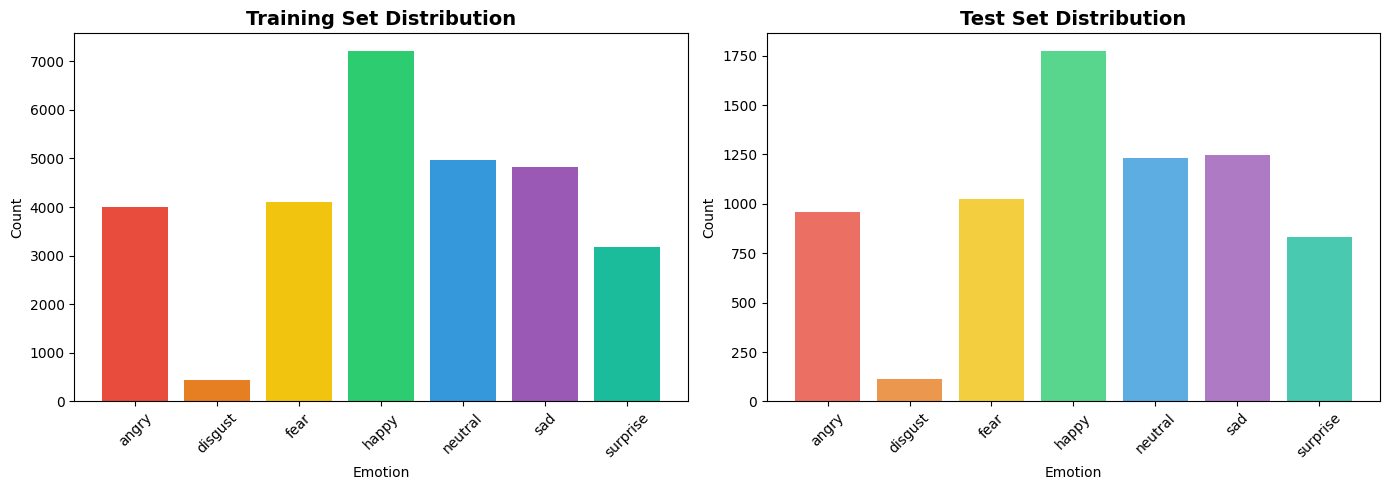

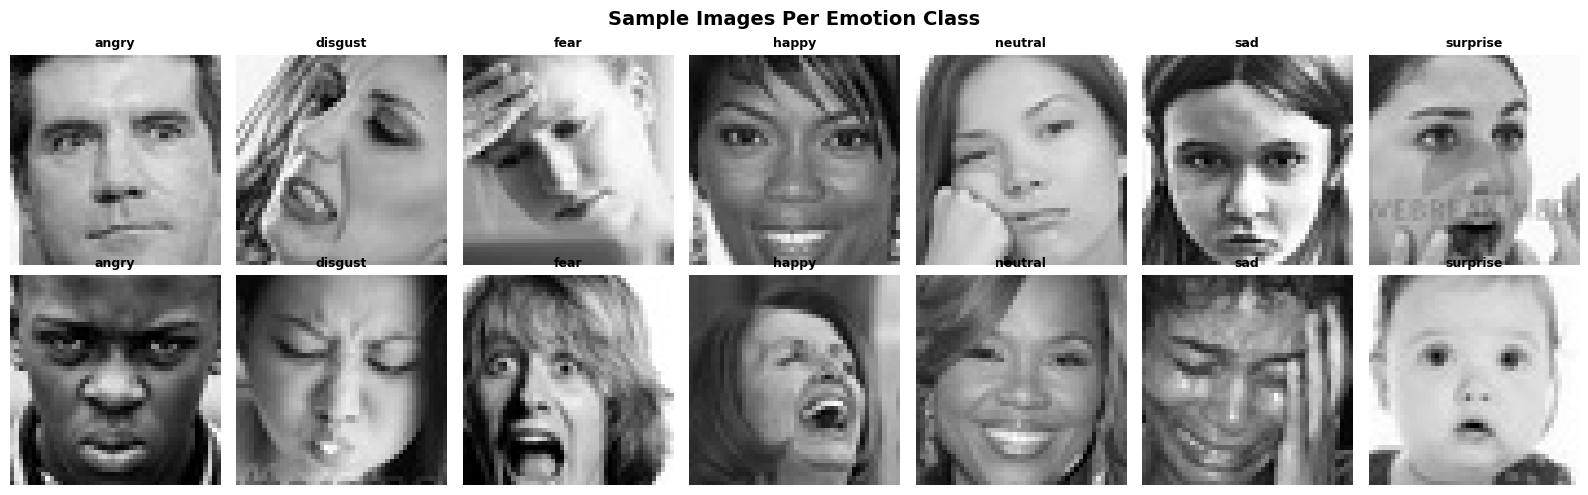

In [16]:
emotion_labels = sorted(os.listdir(train_dir))
print(f"Detected emotion classes: {emotion_labels}")

# Count images per class
print("\n=== Dataset Summary ===")
train_counts = {}
test_counts  = {}

for emotion in emotion_labels:
    tp = os.path.join(train_dir, emotion)
    vp = os.path.join(test_dir,  emotion)
    train_counts[emotion] = len(os.listdir(tp)) if os.path.isdir(tp) else 0
    test_counts[emotion]  = len(os.listdir(vp)) if os.path.isdir(vp) else 0
    print(f"{emotion:10s} -> Train: {train_counts[emotion]:5d} | Test: {test_counts[emotion]:4d}")

print(f"\nTotal Train: {sum(train_counts.values())} | Total Test: {sum(test_counts.values())}")

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E74C3C','#E67E22','#F1C40F','#2ECC71','#3498DB','#9B59B6','#1ABC9C']

axes[0].bar(train_counts.keys(), train_counts.values(), color=colors)
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(test_counts.keys(), test_counts.values(), color=colors, alpha=0.8)
axes[1].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample images
fig, axes = plt.subplots(2, len(emotion_labels), figsize=(16, 5))
for i, emotion in enumerate(emotion_labels):
    path = os.path.join(train_dir, emotion)
    imgs = os.listdir(path)
    for row in range(2):
        img = cv2.imread(os.path.join(path, imgs[row]), cv2.IMREAD_GRAYSCALE)
        axes[row, i].imshow(img, cmap='gray')
        axes[row, i].set_title(emotion, fontsize=9, fontweight='bold')
        axes[row, i].axis('off')

plt.suptitle('Sample Images Per Emotion Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
IMG_SIZE   = 48
BATCH_SIZE = 64
NUM_CLASSES = len(emotion_labels)

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Class mapping: {train_generator.class_indices}")
print(f"Num classes detected: {train_generator.num_classes}")

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Num classes detected: 7


In [18]:
def build_emotion_cnn(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential([

        # Block 1
        Conv2D(64, (3,3), padding='same', activation='relu',
               input_shape=input_shape, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),

        # Block 2
        Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),

        # Block 3
        Conv2D(256, (3,3), padding='same', activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv2D(256, (3,3), padding='same', activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.30),

        # Block 4
        Conv2D(512, (3,3), padding='same', activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv2D(512, (3,3), padding='same', activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.30),

        # Classification head
        GlobalAveragePooling2D(),
        Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.50),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.40),
        Dense(num_classes, activation='softmax')
    ])
    return model

model = build_emotion_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,090,759 (19.42 MB)

 Trainable params: 5,085,383 (19.40 MB)

 Non-trainable params: 5,376 (21.00 KB)

In [19]:
EPOCHS = 60

checkpoint = ModelCheckpoint(
    '/content/best_emotion_model.h5',
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print(f"\nBest val accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.1931 - loss: 2.6527
Epoch 1: val_accuracy improved from None to 0.19713, saving model to /content/best_emotion_model.h5



Epoch 1: finished saving model to /content/best_emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 71s 108ms/step - accuracy: 0.2098 - loss: 2.4107 - val_accuracy: 0.1971 - val_loss: 2.1992 - learning_rate: 0.0010
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2453 - loss: 2.1260
Epoch 2: val_accuracy improved from 0.19713 to 0.32906, saving model to /content/best_emotion_model.h5



Epoch 2: finished saving model to /content/best_emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.2580 - loss: 2.0798 - val_accuracy: 0.3291 - val_loss: 1.9171 - learning_rate: 0.0010
Epoch 3/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3523 - loss: 1.8624
Epoch 3: val_accuracy improved from 0.32906 to 0.32934, saving model to /content/best_emotion_model.h5



Epoch 3: finished saving model to /content/best_emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3922 - loss: 1.7832 - val_accuracy: 0.3293 - val_loss: 2.0988 - learning_rate: 0.0010
Epoch 4/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4648 - loss: 1.6193
Epoch 4: val_accuracy improved from 0.32934 to 0.40262, saving model to /content/best_emotion_model.h5



Epoch 4: finished saving model to /content/best_emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.4794 - loss: 1.5916 - val_accuracy: 0.4026 - val_loss: 1.7936 - learning_rate: 0.0010
Epoch 5/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5072 - loss: 1.5121
Epoch 5: val_accuracy improved from 0.40262 to 0.54570, saving model to /content/best_emotion_model.h5


...


Epoch 48: finished saving model to /content/best_emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.7696 - loss: 0.8565 - val_accuracy: 0.6877 - val_loss: 1.1319 - learning_rate: 6.2500e-05
Epoch 49/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7738 - loss: 0.8490
Epoch 49: val_accuracy did not improve from 0.68766
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7733 - loss: 0.8533 - val_accuracy: 0.6860 - val_loss: 1.1365 - learning_rate: 6.2500e-05
Epoch 50/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7732 - loss: 0.8410
Epoch 50: val_accuracy improved from 0.68766 to 0.68891, saving model to /content/best_emotion_model.h5



Epoch 50: finished saving model to /content/best_emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.7734 - loss: 0.8451 - val_accuracy: 0.6889 - val_loss: 1.1234 - learning_rate: 6.2500e-05
Epoch 51/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7848 - loss: 0.8260
Epoch 51: val_accuracy improved from 0.68891 to 0.69044, saving model to /content/best_emotion_model.h5



Epoch 51: finished saving model to /content/best_emotion_model.h5

Epoch 51: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7803 - loss: 0.8358 - val_accuracy: 0.6904 - val_loss: 1.1338 - learning_rate: 6.2500e-05
Epoch 52/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7862 - loss: 0.8124
Epoch 52: val_accuracy did not improve from 0.69044
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7829 - loss: 0.8229 - val_accuracy: 0.6878 - val_loss: 1.1358 - learning_rate: 3.1250e-05
Epoch 53/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7802 - loss: 0.8216
Epoch 53: val_accuracy did not improve from 0.69044
449/449 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.7849 - loss: 0.8169 - val_accuracy: 0.6870 - val_loss: 1.1405 - learning_rate: 3.1250e-05
Epoch 54/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7907 - loss: 0.8047
Epoch 54: val_accuracy did not improve from 0.


Epoch 56: finished saving model to /content/best_emotion_model.h5

Epoch 56: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.7900 - loss: 0.8049 - val_accuracy: 0.6913 - val_loss: 1.1404 - learning_rate: 3.1250e-05
Epoch 57/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7905 - loss: 0.8005
Epoch 57: val_accuracy improved from 0.69128 to 0.69198, saving model to /content/best_emotion_model.h5



Epoch 57: finished saving model to /content/best_emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7882 - loss: 0.8018 - val_accuracy: 0.6920 - val_loss: 1.1423 - learning_rate: 1.5625e-05
Epoch 58/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7963 - loss: 0.7856
Epoch 58: val_accuracy did not improve from 0.69198
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7918 - loss: 0.7964 - val_accuracy: 0.6886 - val_loss: 1.1447 - learning_rate: 1.5625e-05
Epoch 59/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7937 - loss: 0.7916
Epoch 59: val_accuracy did not improve from 0.69198
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.7925 - loss: 0.7916 - val_accuracy: 0.6906 - val_loss: 1.1455 - learning_rate: 1.5625e-05
Epoch 60/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7973 - loss: 0.7866
Epoch 60: val_accuracy did not improve from 0.69198
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7950 - loss: 0.

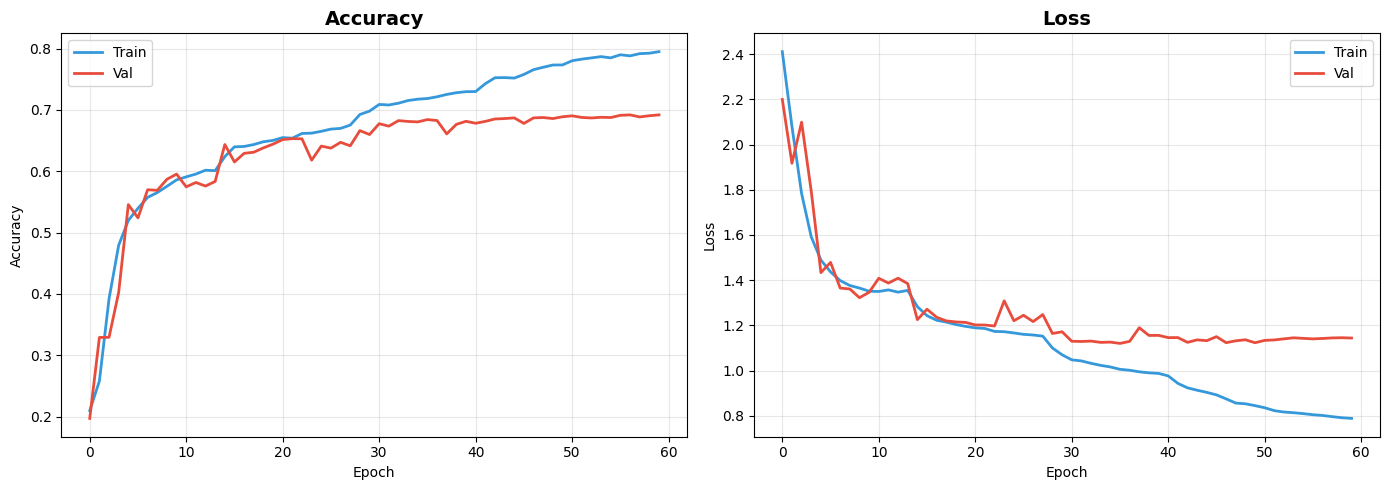

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='#3498DB', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='#E74C3C', linewidth=2)
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='#3498DB', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='#E74C3C', linewidth=2)
axes[1].set_title('Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Test Accuracy: 69.20%
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step

=== Classification Report ===
              precision    recall  f1-score   support

       angry       0.59      0.66      0.62       958
     disgust       0.77      0.63      0.69       111
        fear       0.59      0.46      0.52      1024
       happy       0.89      0.89      0.89      1774
     neutral       0.61      0.70      0.65      1233
         sad       0.58      0.53      0.56      1247
    surprise       0.79      0.83      0.81       831

    accuracy                           0.69      7178
   macro avg       0.69      0.67      0.68      7178
weighted avg       0.69      0.69      0.69      7178



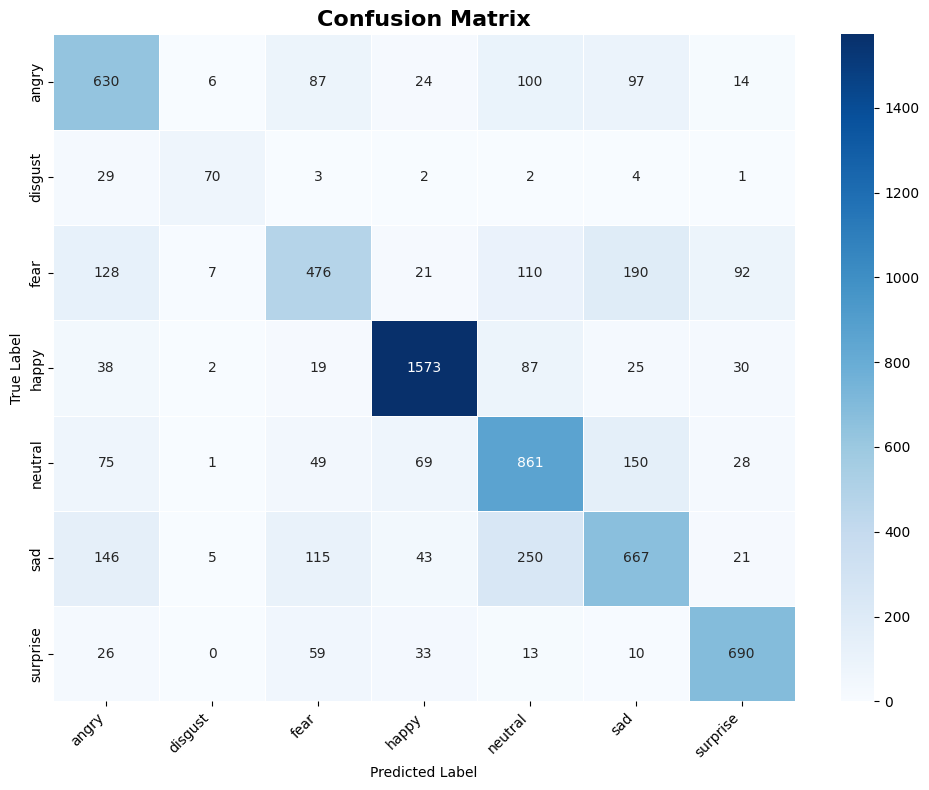

In [21]:
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

test_generator.reset()
y_pred = np.argmax(model.predict(test_generator, verbose=1), axis=1)
y_true = test_generator.classes

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=emotion_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels, linewidths=0.5)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
import json

model.save('/content/emotion_detection_model.h5')

label_map = {str(v): k for k, v in train_generator.class_indices.items()}
with open('/content/emotion_labels.json', 'w') as f:
    json.dump(label_map, f, indent=2)

print("Model saved.")
print(f"Label map: {label_map}")

Model saved.
Label map: {'0': 'angry', '1': 'disgust', '2': 'fear', '3': 'happy', '4': 'neutral', '5': 'sad', '6': 'surprise'}


   FACIAL EMOTION DETECTION — ONE-SHOT WEBCAM CAPTURE

Allow camera access when prompted, then click Capture.

Frame captured: 640x480px
Running detection...

  RESULT: 😄 HAPPY (99.3%)

All scores:
  happy     :  99.3%  ███████████████████
  neutral   :   0.5%  
  angry     :   0.1%  
  sad       :   0.0%  
  surprise  :   0.0%  
  fear      :   0.0%  
  disgust   :   0.0%  


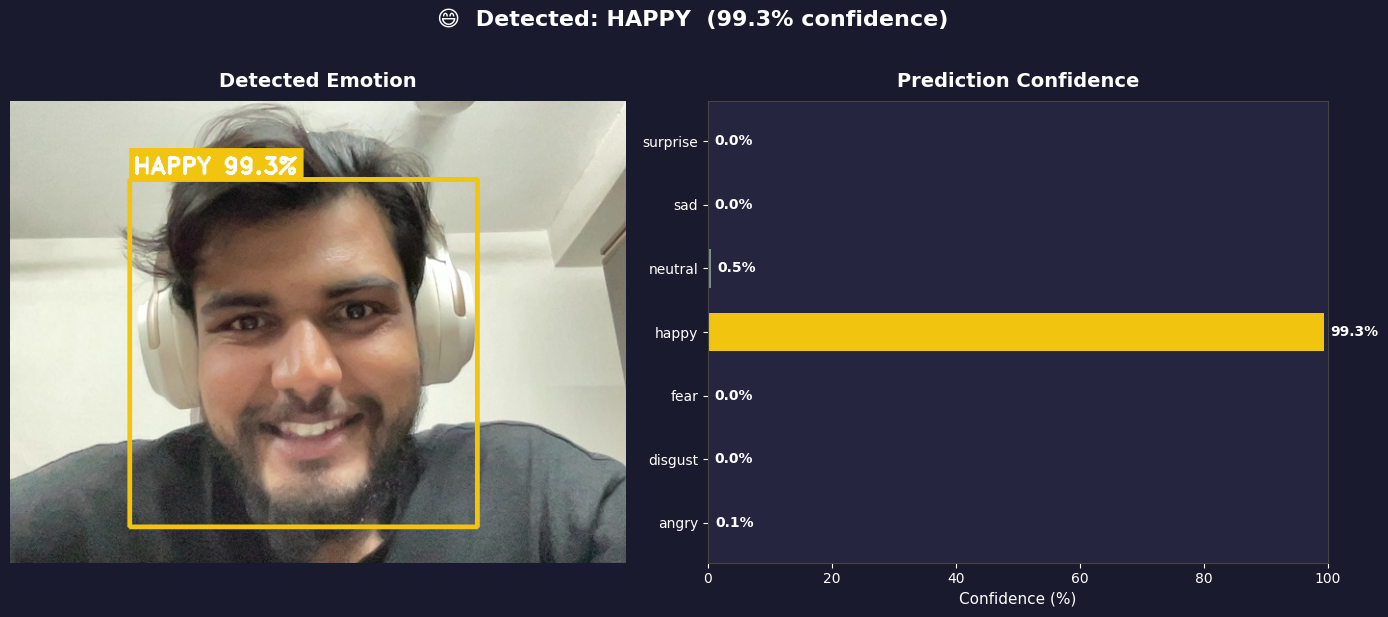

In [25]:
import tensorflow as tf
import numpy as np
import cv2, base64, json, io
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image

# Load model and labels
model      = tf.keras.models.load_model('/content/emotion_detection_model.h5')
with open('/content/emotion_labels.json') as f:
    label_map = json.load(f)
emotion_labels_ordered = [label_map[str(i)] for i in range(len(label_map))]

EMOTION_EMOJI = {
    'angry':'😠','disgust':'🤢','fear':'😨',
    'happy':'😄','neutral':'😐','sad':'😢','surprise':'😲'
}
EMOTION_COLOR = {
    'angry':'#E74C3C','disgust':'#8E44AD','fear':'#2C3E50',
    'happy':'#F1C40F','neutral':'#7F8C8D','sad':'#3498DB','surprise':'#E67E22'
}

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def preprocess_face(face_img):
    face = cv2.resize(face_img, (48, 48))
    if len(face.shape) == 3:
        face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    face = face.astype('float32') / 255.0
    return np.expand_dims(np.expand_dims(face, -1), 0)

def detect_emotion_from_frame(frame_array):
    img_bgr  = cv2.cvtColor(frame_array, cv2.COLOR_RGB2BGR)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces    = face_cascade.detectMultiScale(img_gray, 1.1, 5, minSize=(30,30))
    annotated = img_bgr.copy()
    result    = {'faces_found': len(faces), 'emotions': []}

    if len(faces) == 0:
        cv2.putText(annotated, 'No face detected', (20,50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,255), 2)
        return cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB), result

    for (x, y, w, h) in faces:
        pad  = int(0.1 * w)
        x1,y1 = max(0,x-pad), max(0,y-pad)
        x2,y2 = min(img_bgr.shape[1],x+w+pad), min(img_bgr.shape[0],y+h+pad)

        preds        = model.predict(preprocess_face(img_gray[y1:y2, x1:x2]), verbose=0)[0]
        emotion_name = emotion_labels_ordered[np.argmax(preds)]
        confidence   = float(np.max(preds)) * 100

        result['emotions'].append({
            'emotion': emotion_name, 'confidence': confidence,
            'all_scores': {emotion_labels_ordered[i]: float(preds[i])*100
                           for i in range(len(emotion_labels_ordered))}
        })

        c = tuple(int(EMOTION_COLOR[emotion_name].lstrip('#')[i:i+2],16) for i in (4,2,0))
        cv2.rectangle(annotated, (x1,y1), (x2,y2), c, 3)
        label = f"{emotion_name.upper()} {confidence:.1f}%"
        (lw,lh),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_DUPLEX, 0.8, 2)
        cv2.rectangle(annotated, (x1,y1-lh-14), (x1+lw+8,y1), c, -1)
        cv2.putText(annotated, label, (x1+4,y1-6),
                    cv2.FONT_HERSHEY_DUPLEX, 0.8, (255,255,255), 2)

    return cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB), result

# Webcam JS — opens camera, waits for single button click
WEBCAM_JS = """
async function captureWebcam() {
    const video  = document.createElement('video');
    const canvas = document.createElement('canvas');
    const div    = document.createElement('div');
    const btn    = document.createElement('button');
    const status = document.createElement('p');

    div.style.cssText    = `font-family:sans-serif;text-align:center;padding:16px;
                             background:#1a1a2e;border-radius:12px;max-width:600px;margin:0 auto;`;
    video.style.cssText  = `border-radius:8px;width:100%;max-width:560px;
                             border:2px solid #4ecdc4;display:block;margin:0 auto 12px;`;
    btn.style.cssText    = `background:#4ecdc4;color:#1a1a2e;border:none;
                             padding:12px 32px;font-size:16px;font-weight:bold;
                             border-radius:8px;cursor:pointer;margin:8px;`;
    status.style.cssText = `color:#ccc;font-size:14px;margin:8px 0;`;

    btn.innerText    = '📷  Capture & Detect Emotion';
    status.innerText = 'Camera loading...';
    div.appendChild(status);
    div.appendChild(video);
    div.appendChild(btn);
    document.body.appendChild(div);

    const stream = await navigator.mediaDevices.getUserMedia({ video: true });
    video.srcObject = stream;
    await video.play();
    status.innerText = '✅ Camera ready — press the button when ready!';

    return new Promise(resolve => {
        btn.onclick = () => {
            canvas.width  = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(t => t.stop());
            video.srcObject  = null;
            status.innerText = '⏳ Detecting emotion...';
            btn.disabled     = true;
            resolve(canvas.toDataURL('image/jpeg', 0.95));
        };
    });
}
captureWebcam();
"""

# ── Run ───────────────────────────────────────────────────────────────────────
print("="*55)
print("   FACIAL EMOTION DETECTION — ONE-SHOT WEBCAM CAPTURE")
print("="*55)
print("\nAllow camera access when prompted, then click Capture.\n")

img_data_url = eval_js(WEBCAM_JS)
img_bytes    = b64decode(img_data_url.split(',')[1])
frame_array  = np.array(Image.open(io.BytesIO(img_bytes)).convert('RGB'))

print(f"Frame captured: {frame_array.shape[1]}x{frame_array.shape[0]}px")
print("Running detection...\n")

annotated_frame, result = detect_emotion_from_frame(frame_array)

# ── Display result ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')

axes[0].imshow(annotated_frame)
axes[0].set_title('Detected Emotion', color='white', fontsize=14, fontweight='bold', pad=10)
axes[0].axis('off')
axes[0].set_facecolor('#252540')

if result['faces_found'] > 0:
    top    = result['emotions'][0]
    scores = top['all_scores']
    colors = [EMOTION_COLOR.get(e, '#888') for e in scores]

    bars = axes[1].barh(list(scores.keys()), list(scores.values()),
                         color=colors, edgecolor='none', height=0.6)
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel('Confidence (%)', color='white', fontsize=11)
    axes[1].set_title('Prediction Confidence', color='white', fontsize=14,
                       fontweight='bold', pad=10)
    axes[1].tick_params(colors='white')
    axes[1].set_facecolor('#252540')
    for spine in axes[1].spines.values():
        spine.set_edgecolor('#444')
    for bar, score in zip(bars, scores.values()):
        axes[1].text(score+1, bar.get_y()+bar.get_height()/2,
                     f'{score:.1f}%', va='center', color='white',
                     fontsize=10, fontweight='bold')

    detected   = top['emotion']
    confidence = top['confidence']
    emoji      = EMOTION_EMOJI.get(detected, '')
    fig.suptitle(f'{emoji}  Detected: {detected.upper()}  ({confidence:.1f}% confidence)',
                 color='white', fontsize=16, fontweight='bold', y=1.02)

    print("="*50)
    print(f"  RESULT: {emoji} {detected.upper()} ({confidence:.1f}%)")
    print("="*50)
    print("\nAll scores:")
    for emo, score in sorted(scores.items(), key=lambda x: -x[1]):
        print(f"  {emo:10s}: {score:5.1f}%  {'█'*int(score/5)}")
else:
    axes[1].text(0.5, 0.5, 'No face\ndetected', ha='center', va='center',
                 color='white', fontsize=16, transform=axes[1].transAxes)
    axes[1].set_facecolor('#252540')
    axes[1].axis('off')
    print("\n⚠️  No face detected. Try better lighting and face the camera directly.")

axes[0].set_facecolor('#252540')
plt.tight_layout()
plt.savefig('/content/emotion_result.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()